In [32]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import sys

sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [34]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [35]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=True,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 600)
Resulting SSp_spikes ephys data shape is (NxT): (69, 600)
Resulting VAL_spikes ephys data shape is (NxT): (168, 600)
Resulting GPe_spikes ephys data shape is (NxT): (120, 600)
Resulting CP_spikes ephys data shape is (NxT): (172, 600)
Resulting MOp_spikes ephys data shape is (NxT): (178, 600)


In [36]:
df__ = dt.add_pca_df(df_)

In [37]:
perturb_td = pyal.restrict_to_interval(df__, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td = dt.add_bhv(perturb_td)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

In [38]:
window = 20
k = 5
res = {}
areas = ['bhv', 'MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    if area != 'bhv':
        label = f'{area}_rates_pca'
    else:
        label = area
    y = np.array(perturb_td_shuff.values_Sol_direction.values.tolist())
    X = np.stack(perturb_td_shuff[label].values)
    res[area], times = decode.moving_window_decoding(
        X,
        y,
        cv=StratifiedKFold(n_splits=k),
        window_length_bin=window,
        step_bin=2,
    )

  0%|          | 0/241 [00:00<?, ?it/s]

100%|██████████| 241/241 [00:07<00:00, 33.44it/s]


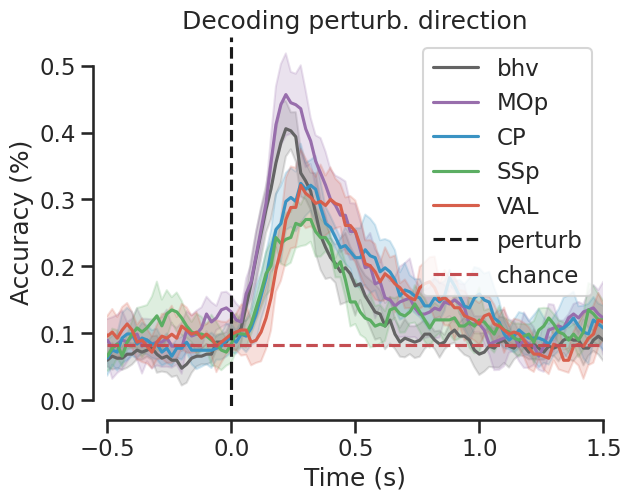

In [81]:
with vizutils.apply_plot_style():

    fig, ax = plt.subplots()
    for area in areas:
        vizutils.shaded_errorbar(ax, times-2, res[area], color=getattr(colors, f'{area}_light'), label=area)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('Time (s)')
    ax.axvline(0, color='k', linestyle='dashed', label='perturb')
    ax.axhline(1/12, color='r', linestyle='dashed', label='chance')
    ax.set_title('Decoding perturb. direction')
    ax.legend()
    # fig.savefig('decoding_accuracy.pdf', bbox_inches='tight')

In [67]:
# ── Regression: each neural area → all bhv keypoints, whole trial concatenated ──
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

k            = 5
neural_areas = ['MOp', 'CP', 'SSp', 'VAL']

# concatenate all time bins: (n_trials × T, n_features)
y_bhv = np.stack(perturb_td_shuff['bhv'].values)          # (n_trials, T, n_bhv)
n_trials, T, n_bhv = y_bhv.shape
Y_flat = y_bhv.reshape(n_trials * T, n_bhv)

reg_res = {}
for area in neural_areas:
    X = np.stack(perturb_td_shuff[f'{area}_rates_pca'].values)  # (n_trials, T, n_pcs)
    X_flat = X.reshape(n_trials * T, -1)
    scores = cross_val_score(
        Ridge(alpha=1.0), X_flat, Y_flat,
        scoring=subspaces.default_scorer,
        cv=k,
    )
    reg_res[area] = scores   # (k_folds,)
    print(f"{area}: R² = {scores.mean():.3f} ± {scores.std():.3f}")



MOp: R² = 0.238 ± 0.003
CP: R² = 0.138 ± 0.007
SSp: R² = 0.142 ± 0.009
VAL: R² = 0.127 ± 0.016


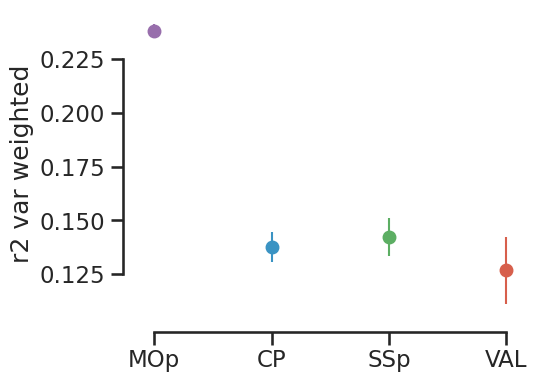

In [77]:
# ── Plot regression R² per area (whole-trial) ────────────────────────────────
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(5, 4))
    for i, area in enumerate(neural_areas):
        m = reg_res[area].mean()
        s = reg_res[area].std()
        c = getattr(colors, f'{area}_light')
        # ax.bar(i, m, color=c, label=area, width=0.6)
        ax.errorbar(i, m, yerr=s, fmt='o', color=c, elinewidth=1.5, capsize=0)

    ax.set_xticks(range(len(neural_areas)))
    ax.set_xticklabels(neural_areas)
    ax.set_ylabel('r2 var weighted')
    # ax.set_title('Neural → kinematics (bhv) regression\nwhole trial concatenated')
    # ax.axhline(0, color='k', lw=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # fig.tight_layout()
    fig.savefig('regression_bhv.pdf', bbox_inches='tight')
plt.show()
